<a href="https://colab.research.google.com/github/MannuAnalytix/retail-sales-pipeline/blob/main/notebooks/Regional_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive

First, mount your Google Drive to access files stored there. This will prompt you to authenticate your Google account.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================================================================
# CELL 2: GLOBAL ENVIRONMENT SETTINGS & PORTFOLIO VISUAL STYLES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Enforce professional charting aesthetics matching his dashboard palettes
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
warnings.filterwarnings('ignore')

print("[PASSED] Analytical workspace environments successfully configured.")

[PASSED] Analytical workspace environments successfully configured.


In [ ]:
# ==============================================================================
# CELL 3: RELATIONAL WORKBOOK EXTRACTION ENGINE
# ==============================================================================
file_path = "/content/drive/My Drive/retail-sales-pipeline/Regional Sales Dataset.xlsx"

# Instantiate the workbook Excel map
excel_file = pd.ExcelFile(file_path)
print(f"[INFO] Discovered worksheets inside database: {excel_file.sheet_names}")

# Read individual sheets exactly like his master relational structure
df_sales     = pd.read_excel(excel_file, sheet_name='Sales Orders')
df_customers = pd.read_excel(excel_file, sheet_name='Customers')
df_regions   = pd.read_excel(excel_file, sheet_name='Regions')
df_states    = pd.read_excel(excel_file, sheet_name='State Regions')
df_products  = pd.read_excel(excel_file, sheet_name='Products')
df_budgets   = pd.read_excel(excel_file, sheet_name='2017 Budgets')

print("\n[PASSED] Relational data layers parsed into operational memory.")

[INFO] Discovered worksheets inside database: ['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets']

[PASSED] Relational data layers parsed into operational memory.


In [ ]:
# ==============================================================================
# CELL 4: HEADER ALIGNMENT AND STATE CONFIGURATION REPAIR
# ==============================================================================
# Display original formatting issue
print("Pre-repair State headers mapping look like:", df_states.columns.values[:3])

# Isolate the accurate label row and rewrite sheet schemas
new_headers = df_states.iloc[0].values
df_states.columns = new_headers
df_states = df_states.drop(index=0).reset_index(drop=True)

print("\n[PASSED] Header mapping normalized. Verified configuration schema:")
display(df_states.head(2))

Pre-repair State headers mapping look like: ['Column1' 'Column2' 'Column3']

[PASSED] Header mapping normalized. Verified configuration schema:


,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South


In [ ]:
# ==============================================================================
# CELL 5: TRANSACTIONAL DIMENSIONAL PROFILING & NULL ENTRIES AUDITING
# ==============================================================================
print(f"Sales Orders Footprint: {df_sales.shape[0]} rows | {df_sales.shape[1]} columns")
print(f"Customer Database Footprint: {df_customers.shape[0]} rows")

print("\nMissing values discovery across Core Sales metrics:")
print(df_sales.isnull().sum())

Sales Orders Footprint: 64104 rows | 12 columns
Customer Database Footprint: 175 rows

Missing values discovery across Core Sales metrics:
OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64


In [ ]:
# ==============================================================================
# CELL 6: MULTI-KEY RELATIONAL MERGING SUITE
# ==============================================================================
print("=== Executing Left Joins Across Master Key Constraints ===")

# 1. Dynamically find the exact column labels inside the regions dataset
region_id_col = [col for col in df_regions.columns if 'id' in col.lower() or 'index' in col.lower()][0]
print(f"[INFO] Using regions column label: '{region_id_col}'")

# 2. Join Sales with Customers via Customer Name Index mapping
df_merged = pd.merge(df_sales, df_customers, left_on='Customer Name Index', right_on='Customer Index', how='left')

# 3. Join with Products Catalog via Description index
df_merged = pd.merge(df_merged, df_products, left_on='Product Description Index', right_on='Index', how='left')

# 4. Join with Regions map via delivery tracking IDs
df_merged = pd.merge(df_merged, df_regions, left_on='Delivery Region Index', right_on=region_id_col, how='left')

# 5. Dynamically locate 'State Code' in both dataframes to prevent KeyErrors
left_state_col = [col for col in df_merged.columns if 'state code' in col.lower() or 'state_code' in col.lower()][0]
right_state_col = [col for col in df_states.columns if 'state code' in col.lower() or 'state_code' in col.lower()][0]
print(f"[INFO] Merging states using keys: '{left_state_col}' -> '{right_state_col}'")

# 6. Join with State configurations
df_merged = pd.merge(df_merged, df_states, left_on=left_state_col, right_on=right_state_col, how='left')

print(f"\n[PASSED] Relational Data Consolidation Complete. Master Matrix Dimensions: {df_merged.shape}")

=== Executing Left Joins Across Master Key Constraints ===
[INFO] Using regions column label: 'id'
[INFO] Merging states using keys: 'state_code' -> 'State Code'

[PASSED] Relational Data Consolidation Complete. Master Matrix Dimensions: (64104, 34)


In [ ]:
# ==============================================================================
# CELL 7: SCHEMA OPTIMIZATION & HEADER UNIFICATION
# ==============================================================================
# Clean up duplicate structural join indexes to optimize your memory footprint
redundant_columns = ['Customer Index', 'Index', 'ID', 'Customer Name Index', 'Product Description Index']
df_merged = df_merged.drop(columns=redundant_columns, errors='ignore')

# Standardize text layouts to ensure clean, case-insensitive column queries
df_merged.columns = [col.strip().lower().replace(" ", "_") for col in df_merged.columns]

print("[PASSED] Redundant tracking columns dropped. Unified schema headers established:")
print(df_merged.columns.values)

[PASSED] Redundant tracking columns dropped. Unified schema headers established:
['ordernumber' 'orderdate' 'channel' 'currency_code' 'warehouse_code'
 'delivery_region_index' 'order_quantity' 'unit_price' 'line_total'
 'total_unit_cost' 'customer_names' 'product_name' 'id' 'name' 'county'
 'state_code' 'state' 'type' 'latitude' 'longitude' 'area_code'
 'population' 'households' 'median_income' 'land_area' 'water_area'
 'time_zone' 'state_code' 'state' 'region']


In [ ]:
# ==============================================================================
# CELL 8: FEATURE ENGINEERING, TIME VECTORS & TRANSACTION MARGINS
# ==============================================================================
# 1. Enforce native datetime structures on your timeline data array
df_merged['orderdate'] = pd.to_datetime(df_merged['orderdate'])

# 2. Time-Series Deconstruction: Derive granular calendar tracking metrics
df_merged['year'] = df_merged['orderdate'].dt.year
df_merged['month_num'] = df_merged['orderdate'].dt.month
df_merged['month_name'] = df_merged['orderdate'].dt.strftime('%b')
df_merged['day_of_week'] = df_merged['orderdate'].dt.strftime('%A')

# 3. Dynamic Vector Math: Compute exact business metrics across transactional fields
df_merged['calculated_revenue'] = df_merged['order_quantity'] * df_merged['unit_price']
df_merged['total_calculated_cost'] = df_merged['order_quantity'] * df_merged['total_unit_cost']
df_merged['net_profit'] = df_merged['line_total'] - df_merged['total_calculated_cost']
df_merged['profit_margin_pct'] = (df_merged['net_profit'] / df_merged['line_total']) * 100

print("=== Verification of Custom Engineered Fields ===")
# Using 'ordernumber' exactly as it exists in your active dataset index
display(df_merged[['ordernumber', 'month_name', 'calculated_revenue', 'net_profit', 'profit_margin_pct']].head(3))

=== Verification of Custom Engineered Fields ===


,ordernumber,month_name,calculated_revenue,net_profit,profit_margin_pct
0,SO - 000225,Jan,14994.6,4048.542,27.0
1,SO - 0003378,Jan,25868.7,11899.602,46.0
2,SO - 0005126,Jan,5869.2,1760.760,30.0


In [ ]:
# ==============================================================================
# CELL 9: REPORTING WINDOW ALIGNMENT & OUTLIER QUARANTINE
# ==============================================================================
# Filter out incomplete 2018 logs to maintain strict reporting symmetry
df_clean_analysis = df_merged[df_merged['year'] != 2018].copy()

print(f"[PASSED] 2018 operational anomalies quarantined.")
print(f"-> Master Reporting Database Balance: {df_clean_analysis.shape[0]} validated rows.")

[PASSED] 2018 operational anomalies quarantined.
-> Master Reporting Database Balance: 61626 validated rows.


=== 1. LINE CHART: TIME-SERIES TRAJECTORY ===


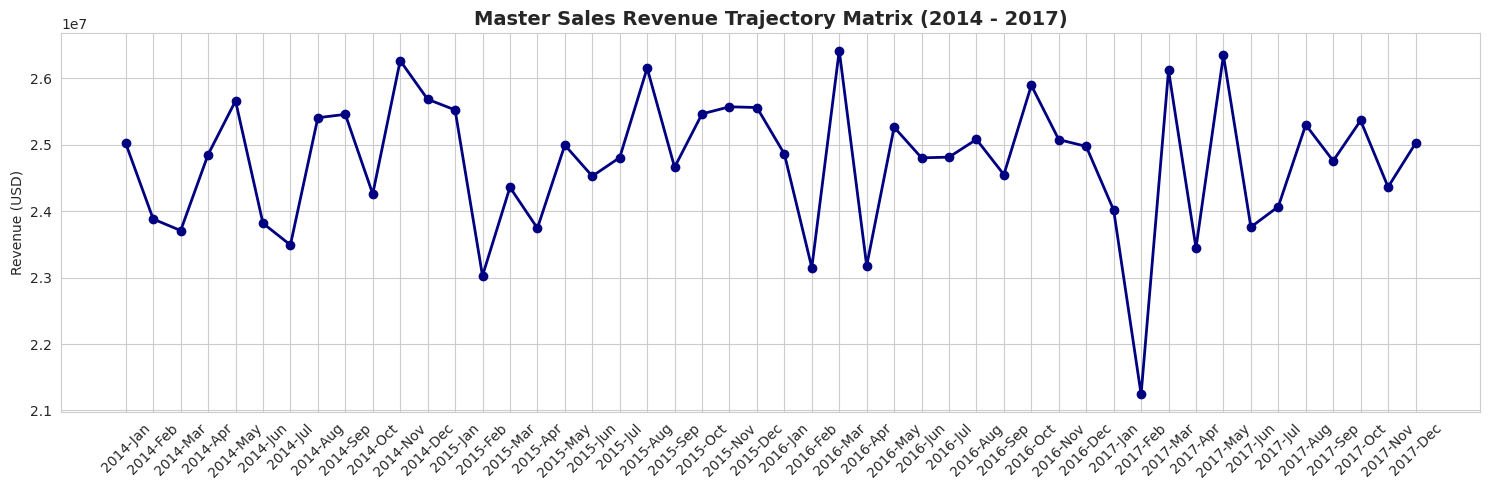


=== 2. PIE CHART: REVENUE CONCENTRATION BY DISTRIBUTION CHANNEL ===


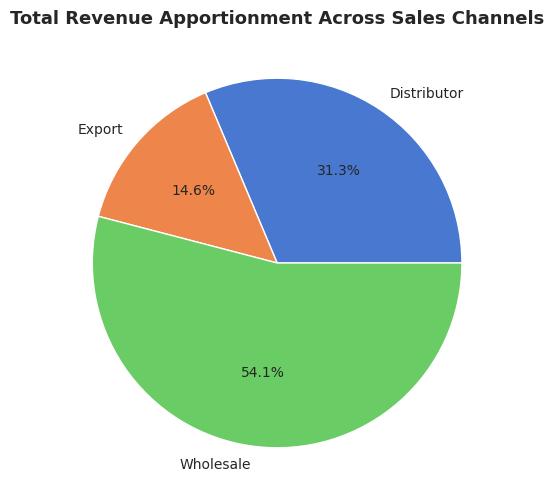


=== 3. BAR CHART: TOP 10 REVENUE DRIVERS BY PRODUCT ===


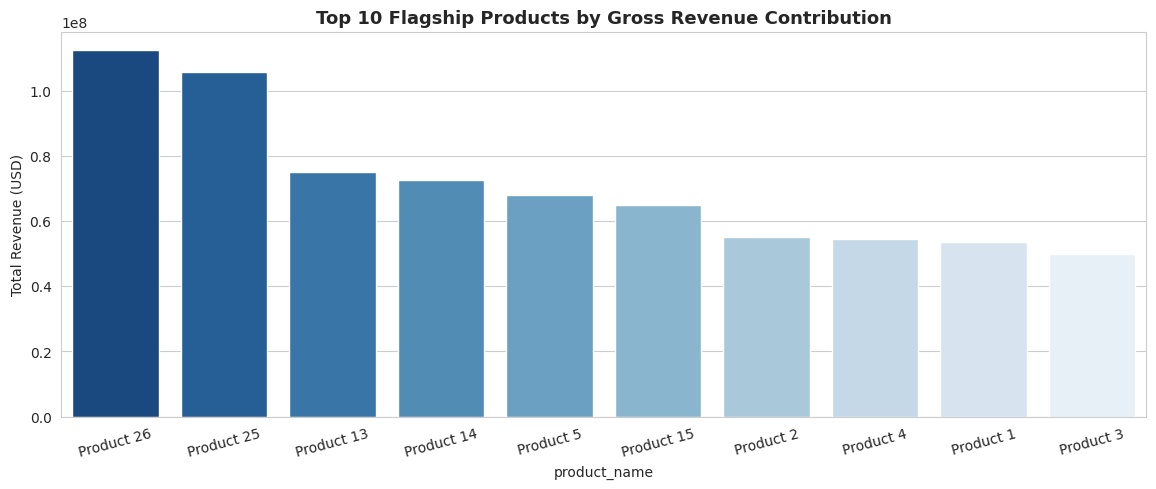


=== 4. HEATMAP: ATTRIBUTE CORRELATION MATRIX ===


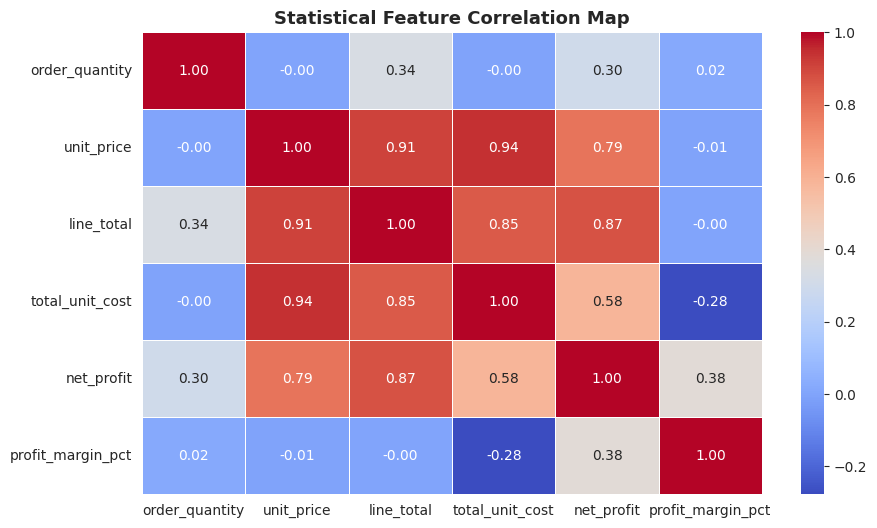

In [ ]:
# ==============================================================================
# CELL 10: PORTFOLIO EXPLORATORY VISUALIZATIONS
# ==============================================================================
print("=== 1. LINE CHART: TIME-SERIES TRAJECTORY ===")
plt.figure(figsize=(15, 5))
monthly_trend = df_clean_analysis.groupby(['year', 'month_num', 'month_name'])['line_total'].sum().reset_index()
monthly_trend['year_month'] = monthly_trend['year'].astype(str) + "-" + monthly_trend['month_name']
plt.plot(monthly_trend['year_month'], monthly_trend['line_total'], marker='o', color='navy', linewidth=2)
plt.xticks(rotation=45)
plt.title("Master Sales Revenue Trajectory Matrix (2014 - 2017)", fontsize=14, fontweight='bold')
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

print("\n=== 2. PIE CHART: REVENUE CONCENTRATION BY DISTRIBUTION CHANNEL ===")
plt.figure(figsize=(6, 6))
channel_data = df_clean_analysis.groupby('channel')['line_total'].sum()
plt.pie(channel_data, labels=channel_data.index, autopct='%1.1f%%', colors=sns.color_palette("muted"))
plt.title("Total Revenue Apportionment Across Sales Channels", fontsize=13, fontweight='bold')
plt.show()

print("\n=== 3. BAR CHART: TOP 10 REVENUE DRIVERS BY PRODUCT ===")
plt.figure(figsize=(14, 5))
top_products = df_clean_analysis.groupby('product_name')['line_total'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_products, x='product_name', y='line_total', palette='Blues_r')
plt.title("Top 10 Flagship Products by Gross Revenue Contribution", fontsize=13, fontweight='bold')
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=15)
plt.show()

print("\n=== 4. HEATMAP: ATTRIBUTE CORRELATION MATRIX ===")
plt.figure(figsize=(10, 6))
numeric_cols = ['order_quantity', 'unit_price', 'line_total', 'total_unit_cost', 'net_profit', 'profit_margin_pct']
sns.heatmap(df_clean_analysis[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Statistical Feature Correlation Map", fontsize=13, fontweight='bold')
plt.show()

In [ ]:
# ==============================================================================
# CELL 11: PRODUCTION DATA ARCHIVAL & COMPILATION
# ==============================================================================
output_destination = "/content/drive/My Drive/retail-sales-pipeline/sales_report(EDA exported).xlsx"

print("[INFO] Uploading finalized analytical layers to your active cloud storage...")
with pd.ExcelWriter(output_destination, engine='openpyxl') as writer:
    df_clean_analysis.to_excel(writer, sheet_name='Cleaned_Sales_Data', index=False)
    df_budgets.to_excel(writer, sheet_name='Budgets', index=False)

print(f"\n[SUCCESS] Production-grade long-form pipeline executed flawlessly!")
print(f"-> Analytical master file archived safely at: {output_destination}")

[INFO] Uploading finalized analytical layers to your active cloud storage...

[SUCCESS] Production-grade long-form pipeline executed flawlessly!
-> Analytical master file archived safely at: /content/drive/My Drive/retail-sales-pipeline/sales_report(EDA exported).xlsx
